# DemandScope · Previsão de vendas em 28 dias
**Lucas Menghi · Walmart/M5 · CRISP-DM**

Este notebook reconstrói o painel real e verifica o desempenho do artefato
congelado. A busca de oito candidatos em quatro origens foi executada por
`scripts/train.py`; aqui apresentamos suas evidências e recalculamos o teste final.
Não é previsão atual de Walmart nem demonstração de economia de estoque.

In [1]:
from pathlib import Path
import sys, json, hashlib
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import joblib
from IPython.display import display, Image
from src.data import load_panel,DEV_END,ORIGINS
from src.models import forecast
from src.metrics import score,intervals
r = json.loads((ROOT/'reports/results.json').read_text(encoding='utf-8'))
artifact = joblib.load(ROOT/'artifacts/forecast.joblib')
freeze = json.loads((ROOT/'reports/freeze.json').read_text(encoding='utf-8'))
assert hashlib.sha256((ROOT/'artifacts/forecast.joblib').read_bytes()).hexdigest()==freeze['artifact_sha256']
print('Artefato congelado:',artifact['spec']['name'],'· treino até',artifact['train_end'])

Artefato congelado: HGB31 · treino até 2016-04-24


## 1. Entendimento do negócio
Prever vendas por loja e departamento nos próximos 28 dias para apoiar capacidade,
planejamento comercial e reposição. Vendas observadas não são demanda não censurada:
sem estoque, rupturas ou pedidos não atendidos, não inferimos demanda perdida.
Sem lead times, margens ou custos, não se calcula pedido ótimo ou economia realizada.

## 2. Dados reais e procedência
[Walmart/M5](https://www.kaggle.com/competitions/m5-forecasting-accuracy/data),
espelho público documentado pela Nixtla. 30.490 séries produto–loja agregadas
por soma em 70 séries loja–departamento. Todas as dez lojas e sete departamentos.
O calendário do espelho não tem `d`; reconstruímos sua sequência. O ID redundante
de produto–loja não é necessário, pois validamos a chave item+loja.
Não publicamos dados brutos ou históricos por item.

In [2]:
panel,calendar,audit = load_panel(ROOT/'data/raw')
display(pd.Series(audit,name='auditoria'))
assert audit['modeled_series']==70 and audit['missing_days']==0
display(panel.groupby('dept_id').agg(series=('series_id','nunique'),units=('y','sum')))
development = panel.loc[panel.day.le(DEV_END)].copy()
print('Origem final do modelo:',development.date.max().date())

product_store_series                                                    30490
stores                                                                     10
departments                                                                 7
modeled_series                                                             70
calendar_days                                                            1969
observed_days                                                            1941
observed_panel_rows                                                    135870
development_end                                                    2016-04-24
test_start                                                         2016-04-25
test_end                                                           2016-05-22
zeros                                                                     363
negative_sales                                                              0
missing_days                                                    

,series,units
dept_id,,
FOODS_1,10,5190400
FOODS_2,10,7795025
FOODS_3,10,32937002
HOBBIES_1,10,5699014
HOBBIES_2,10,541642
HOUSEHOLD_1,10,11722853
HOUSEHOLD_2,10,3041237


Origem final do modelo: 2016-04-24


## 3. Preparação temporal
Backtesting em quatro origens: d1801, d1829, d1857 e d1885; cada uma prevê os
28 dias seguintes sem atualização intermediária. Teste final d1914…d1941,
25/04/2016 a22/05/2016. Todo ajuste e escolha limitados a d1…d1913.

Features de venda: defasagens28/35/56/364, médias7/28 deslocadas28 dias.
Para todo alvo t≤origem+28, a venda mais recente usada é t−28≤origem.
Calendário e SNAP são tratados como conhecidos. Não usamos preço futuro.
Escala local é média28 dias deslocada28, com piso1; modelos globais prevêem y/escala.

In [3]:
from src.features import make_features,NUMERIC
features = make_features(development)
display(features[NUMERIC+['scale']].describe().round(3))
date_origins = development.loc[development.day.isin(ORIGINS),['day','date']].drop_duplicates().sort_values('day')
display(date_origins)
print('As features não incluem o target do dia futuro nem defasagens menores que28.')

,lag28,lag35,lag56,lag364,mean7,mean28,dow_sin,dow_cos,year_sin,year_cos,trend,snap,event,scale
count,130060.000,130060.000,129990.000,108430.000,130060.000,130060.0,133910.000,133910.000,133910.000,133910.000,133910.000,133910.000,133910.000,130060.000
mean,1.007,1.002,1.001,0.927,1.004,1.0,-0.001,0.000,0.039,0.013,2.617,0.329,0.081,488.790
std,0.290,0.267,0.293,0.348,0.125,0.0,0.707,0.707,0.714,0.698,1.512,0.470,0.272,580.008
min,0.000,0.000,0.000,0.000,0.024,1.0,-0.975,-0.901,-1.000,-1.000,0.000,0.000,0.000,1.714
25%,0.830,0.832,0.821,0.710,0.943,1.0,-0.782,-0.901,-0.679,-0.683,1.309,0.000,0.000,141.357
50%,0.972,0.969,0.964,0.888,1.001,1.0,0.000,-0.223,0.079,0.035,2.617,0.000,0.000,296.554
75%,1.159,1.151,1.153,1.103,1.062,1.0,0.782,0.623,0.758,0.703,3.926,1.000,0.000,553.821
max,15.656,5.944,9.655,12.320,3.845,1.0,0.975,1.000,1.000,1.000,5.235,1.000,1.000,3803.536


,day,date
1800,1801,2016-01-03
1828,1829,2016-01-31
1856,1857,2016-02-28
1884,1885,2016-03-27


As features não incluem o target do dia futuro nem defasagens menores que28.


## 4. Comparação e seleção
Oito candidatos: SeasonalNaive7, WeekdayMean8, ETS, ETSLog, Ridge10/Ridge100,
HGB15/HGB31. Estatísticos e ML usam últimos730 dias; referências usam suas
janelas declaradas. Escolha pelo menor WAPE médio das quatro origens.
RMSSE médio do recorte não é WRMSSE oficial M5, e não reivindicamos ranking.

,model,wape,mae,bias,mean_mase7,mean_rmsse
0,HGB31,0.1146,67.4355,-0.0007,0.9335,0.8140
1,HGB15,0.1148,67.6135,-0.0048,0.9404,0.8184
2,Ridge100,0.1258,74.1554,-0.0388,0.9986,0.8608
3,Ridge10,0.1258,74.1559,-0.0388,0.9987,0.8609
4,WeekdayMean8,0.1348,79.3757,-0.0540,1.0034,0.8837
5,ETS,0.1370,80.7436,-0.0406,1.0166,0.9020
6,ETSLog,0.1596,93.5111,-0.1150,1.1044,0.9598
7,SeasonalNaive7,0.1662,97.7741,-0.0572,1.2292,1.0939


model,ETS,ETSLog,HGB15,HGB31,Ridge10,Ridge100,SeasonalNaive7,WeekdayMean8
origin_date,,,,,,,,
2016-01-03,0.1515,0.2263,0.1319,0.1336,0.1350,0.1350,0.2007,0.1532
2016-01-31,0.1311,0.1679,0.1127,0.1092,0.1417,0.1417,0.1650,0.1592
2016-02-28,0.1243,0.1285,0.1117,0.1101,0.1174,0.1174,0.1414,0.1189
2016-03-27,0.1411,0.1159,0.1030,0.1053,0.1090,0.1090,0.1577,0.1080


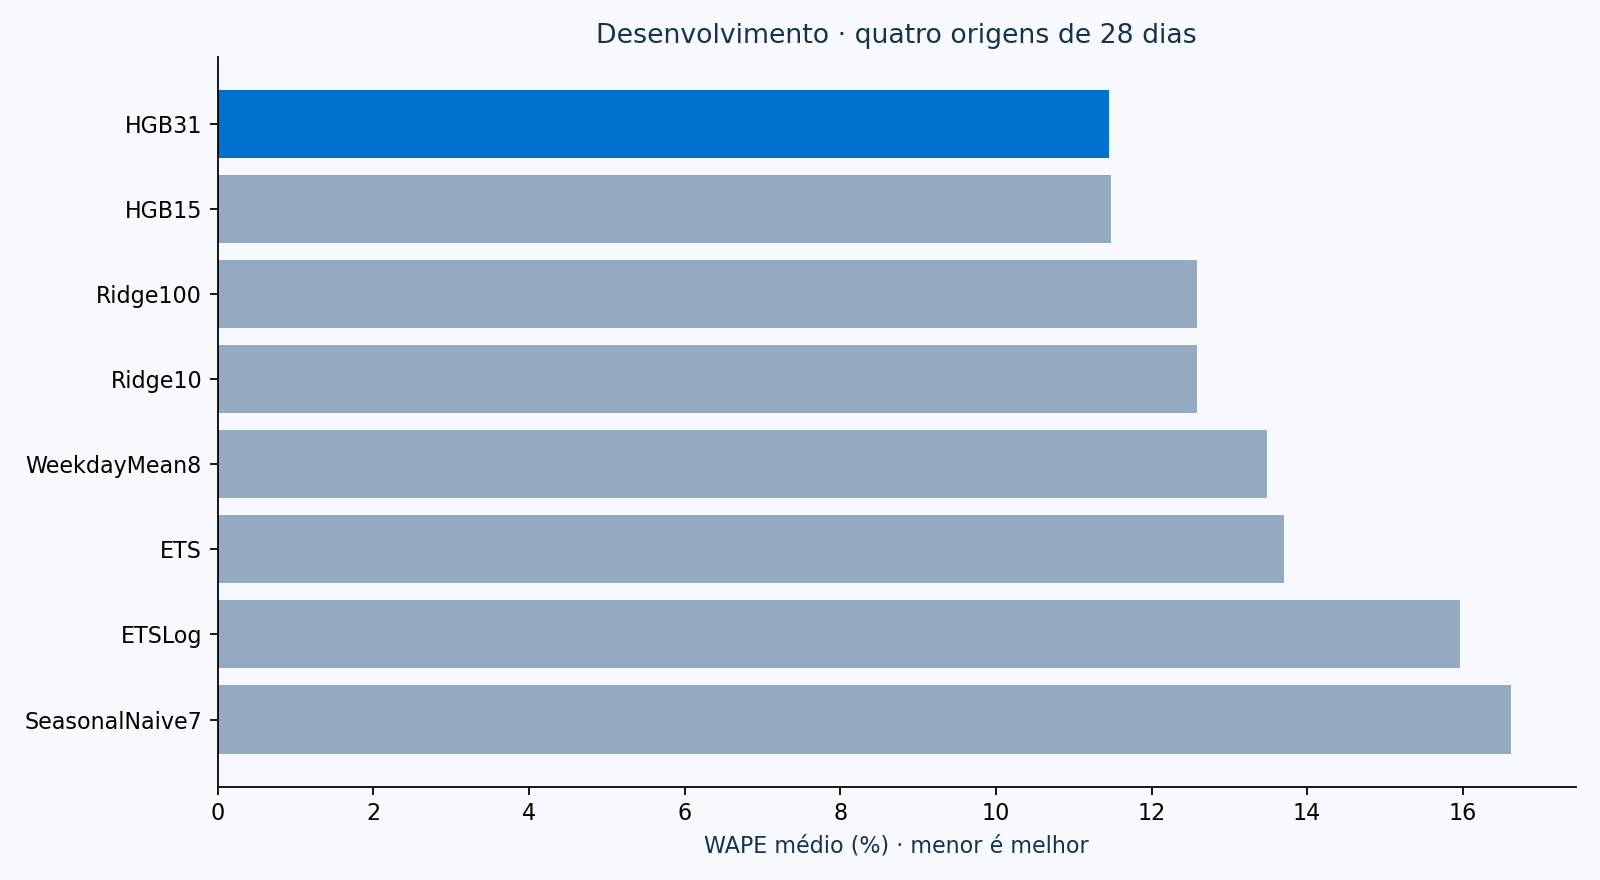

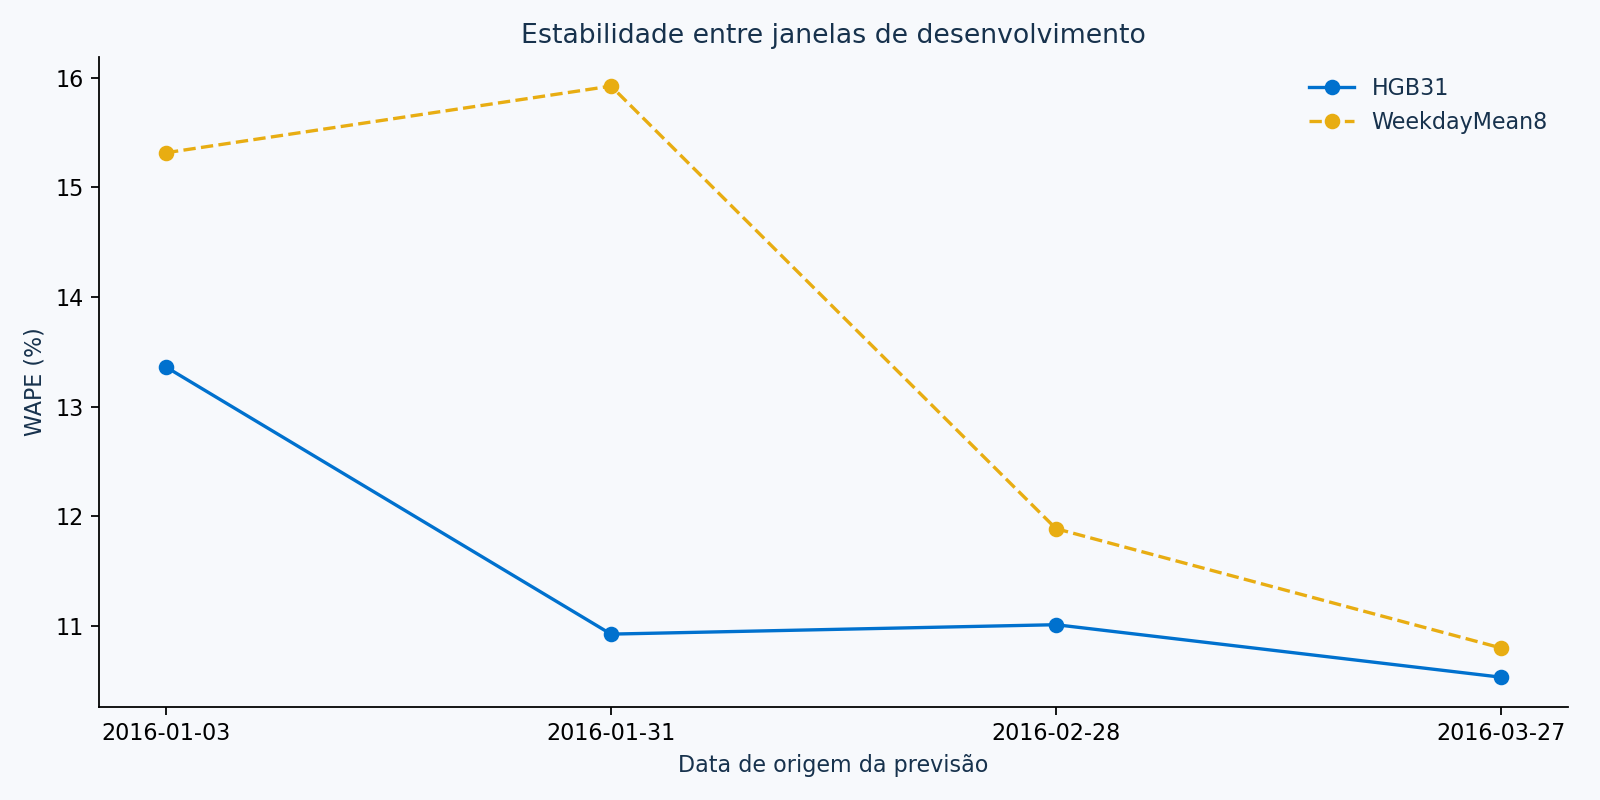

In [4]:
comparison = pd.read_csv(ROOT/'reports/model_comparison.csv')
folds = pd.read_csv(ROOT/'reports/backtest_folds.csv')
assert comparison.iloc[0].model==artifact['spec']['name']
display(comparison.round(4))
display(folds.pivot(index='origin_date',columns='model',values='wape').round(4))
display(Image(filename=str(ROOT/'reports/figures/model_comparison.png')))
display(Image(filename=str(ROOT/'reports/figures/backtest_stability.png')))

## 5. Teste final do modelo congelado
Recalculamos as previsões diretamente com o artefato serializado, sem reajuste ou
seleção com os resultados do teste. WAPE é erro absoluto total / vendas totais,
nas70 séries; dá maior peso aos maiores volumes. Viés mede desvio no total,
sem compensar erro entre dias ou lojas.

wape               9.989289e-02
mae                6.277779e+01
bias              -1.294845e-02
mean_mase7         8.858125e-01
mean_rmsse         7.906104e-01
actual_units       1.231764e+06
predicted_units    1.215815e+06
coverage90         9.137755e-01
dtype: float64

,model,wape,mae,bias,mean_mase7,mean_rmsse,actual_units,predicted_units
0,SeasonalNaive7,0.1321,83.0071,-0.0736,1.1504,1.0274,1231764.0,1141116.0
1,WeekdayMean8,0.1205,75.7247,-0.0421,1.0105,0.8920,1231764.0,1179846.5


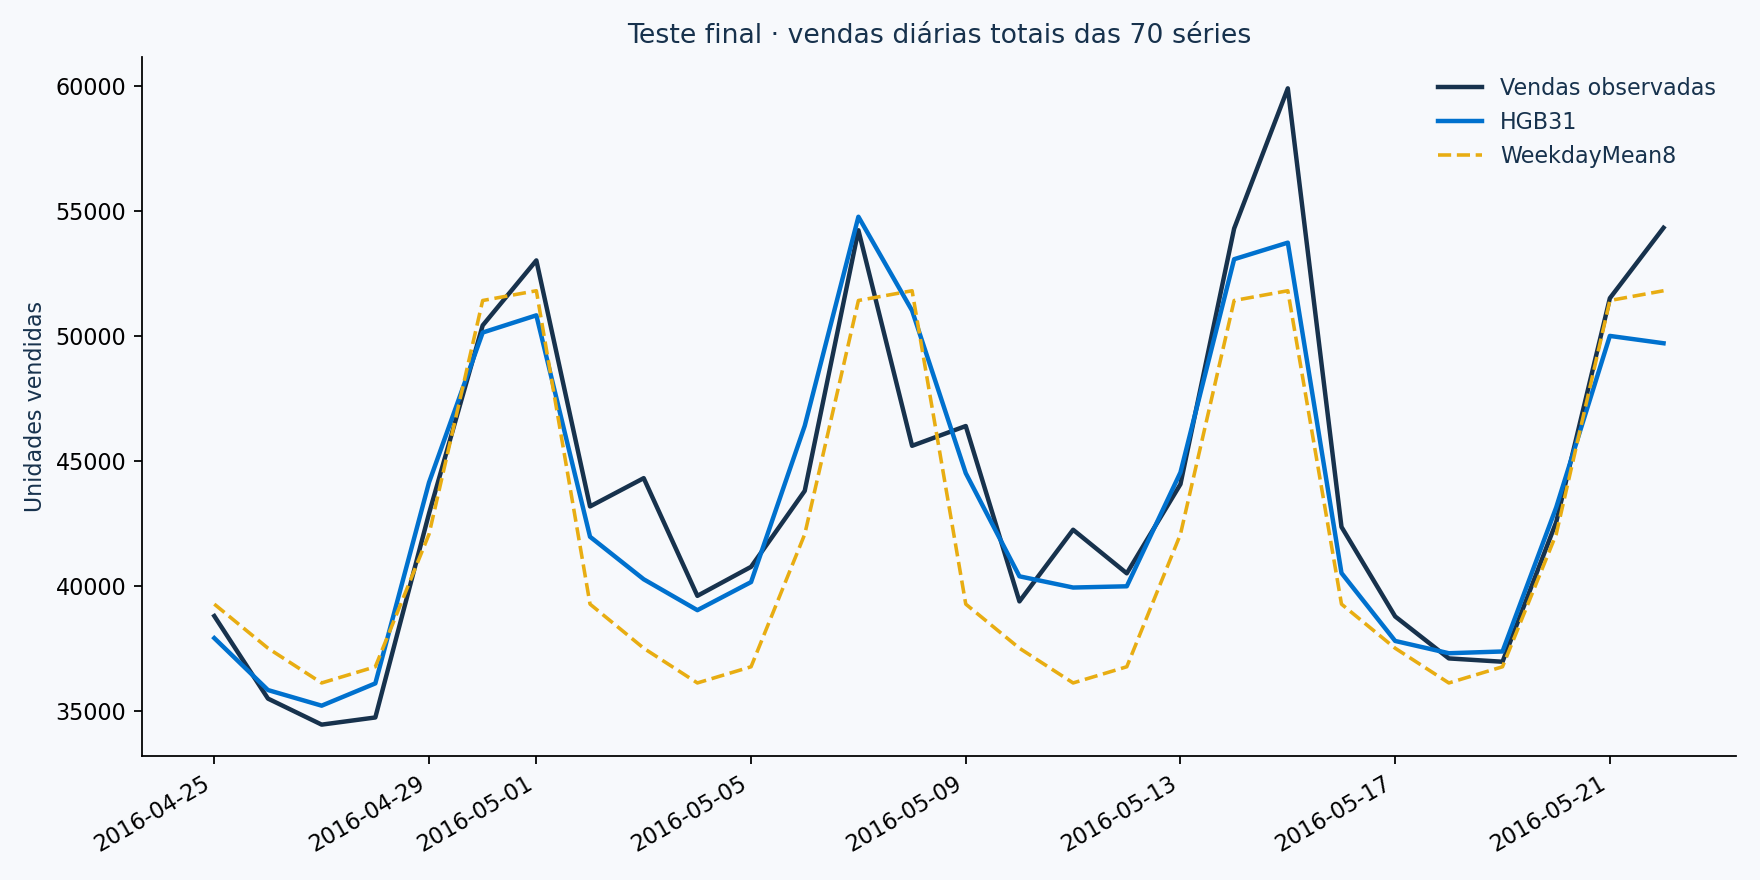

In [5]:
predicted = intervals(forecast(development,calendar,artifact['spec'],artifact['fitted']),artifact['quantiles90'])
actual = panel.loc[panel.day.gt(DEV_END),['series_id','date','y']]
test = predicted.merge(actual,on=['series_id','date'],validate='one_to_one')
metrics = score(test,development)
assert np.isclose(metrics['wape'],r['test']['wape'])
assert np.isclose(metrics['bias'],r['test']['bias'])
coverage = float((test.y.ge(test.lower90)&test.y.le(test.upper90)).mean())
assert np.isclose(coverage,r['test']['coverage90'])
display(pd.Series({**metrics,'coverage90':coverage}))
display(pd.DataFrame(r['baselines']).round(4))
display(Image(filename=str(ROOT/'reports/figures/total_forecast.png')))

## 6. Incerteza e heterogeneidade
Intervalo nominal90% calibrado por departamento, com quantil finito-amostral dos
erros absolutos normalizados nas previsões fora da amostra do candidato escolhido.
Escolha e calibração compartilham janelas; dependência temporal e poucos períodos
limitam garantias. Não há cobertura conjunta dos28 dias ou dos totais.

O exemplo CA_1/FOODS_3 foi fixado previamente. Não é a série escolhida por melhor erro.
HOBBIES_2 e FOODS_1 têm limitações visíveis no teste e precisam de atenção específica.

,department,wape,mae,bias,mean_mase7,mean_rmsse,actual_units,predicted_units,coverage90
0,FOODS_1,0.1667,60.9226,-0.1479,1.1657,1.1458,102359.0,87223.4143,0.8821
1,FOODS_2,0.1058,62.4162,0.0119,0.7581,0.7451,165203.0,167175.7755,0.9250
2,FOODS_3,0.0795,160.4504,-0.0088,0.6648,0.5482,564926.0,559968.9161,0.9500
3,HOBBIES_1,0.1217,44.5861,-0.0124,0.7440,0.6648,102554.0,101284.4784,0.9321
4,HOBBIES_2,0.2466,11.7155,-0.1545,1.0406,1.0564,13302.0,11246.5326,0.8107
5,HOUSEHOLD_1,0.0971,77.0972,0.0351,0.9026,0.6702,222327.0,230136.9977,0.9500
6,HOUSEHOLD_2,0.1020,22.2566,-0.0379,0.9249,0.7037,61093.0,58778.4479,0.9464


,horizon,wape,mae,bias,mean_mase7,mean_rmsse,actual_units,predicted_units
0,1–7,0.0926,54.7926,0.0012,0.7884,0.6805,289814.0,290155.7026
1,8–14,0.1088,69.1529,0.0068,0.9996,0.8633,311512.0,313624.3029
2,15–21,0.1022,68.1543,-0.0326,0.8558,0.7252,326832.0,316182.6432
3,22–28,0.0952,59.0113,-0.0255,0.8994,0.7595,303606.0,295851.9137


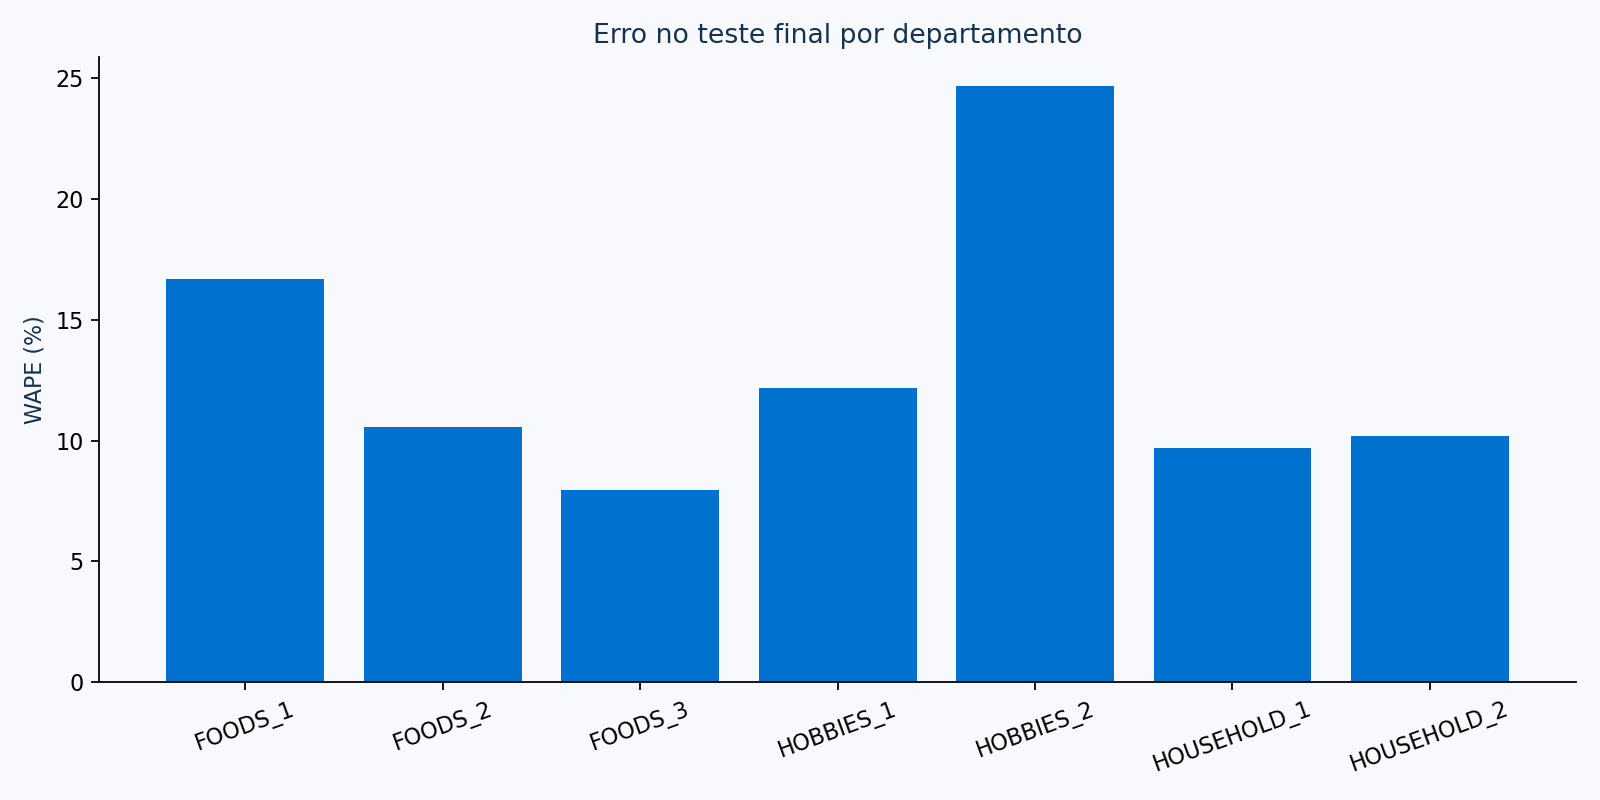

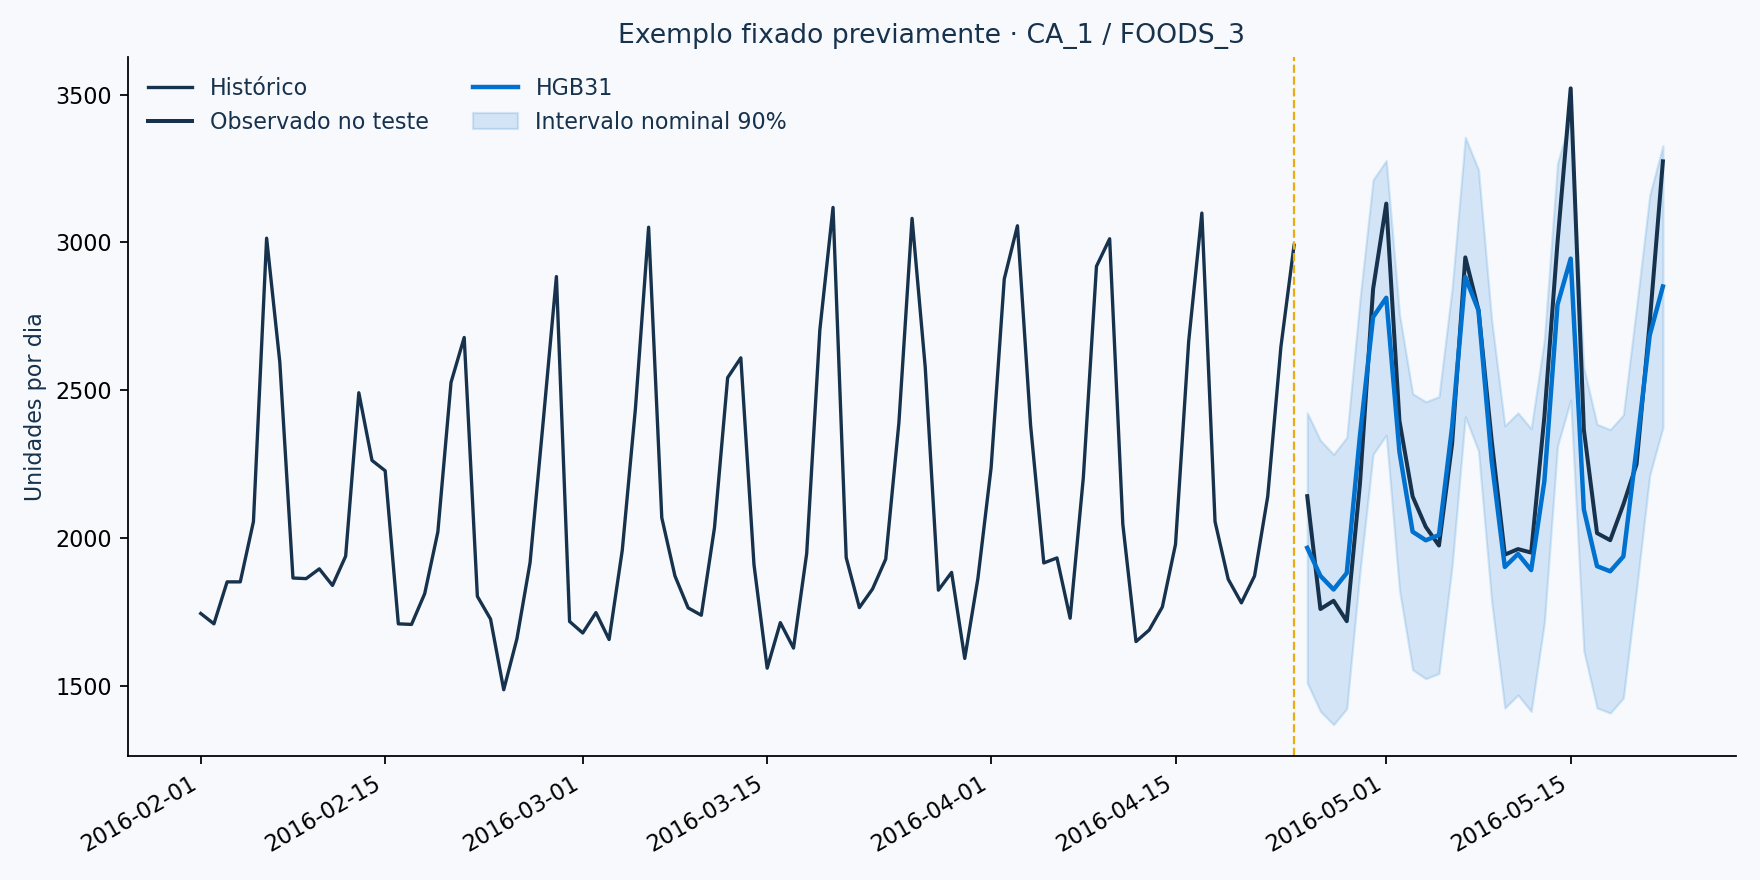

In [6]:
display(pd.read_csv(ROOT/'reports/test_by_department.csv').round(4))
display(pd.read_csv(ROOT/'reports/test_by_horizon.csv').round(4))
display(Image(filename=str(ROOT/'reports/figures/department_error.png')))
display(Image(filename=str(ROOT/'reports/figures/example_forecast.png')))

## 7. Entrega e decisão
O modelo reduziu WAPE neste teste histórico em relação à referência selecionada.
Próximo passo de negócio: dados atuais, disponibilidade de estoque, lead times,
custos/margens, validação externa e piloto controlado. Sem essas informações,
usar previsão como apoio à análise, sem pedidos automáticos ou alegação de ROI.

Entrega: estimador congelado, CLI de28 dias, testes de vazamento, calendário e
inferência, dashboard Streamlit, estudo bilíngue e arte corporativa. Projeto de
Lucas Menghi com assistência de IA, sem vínculo ou endosso de Walmart/Nixtla.
Código original MIT; direitos/regras da fonte M5 preservados.